# Scalar Diffusion

The `diffuse()` function models how a scalar field (temperature, concentration, humidity) spreads across a raster over time. It solves the 2D diffusion equation using an explicit forward-Euler scheme with a 5-point Laplacian stencil:

    du/dt = alpha * laplacian(u)

You can use a uniform diffusivity (single float) or a spatially varying diffusivity raster. The solver auto-selects a stable time step when you don't provide one.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from xrspatial.diffusion import diffuse

## 1. Point source diffusion

Start with a single hot cell in the center of a cold field and watch it spread.

/tmp/ipykernel_145801/274803497.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


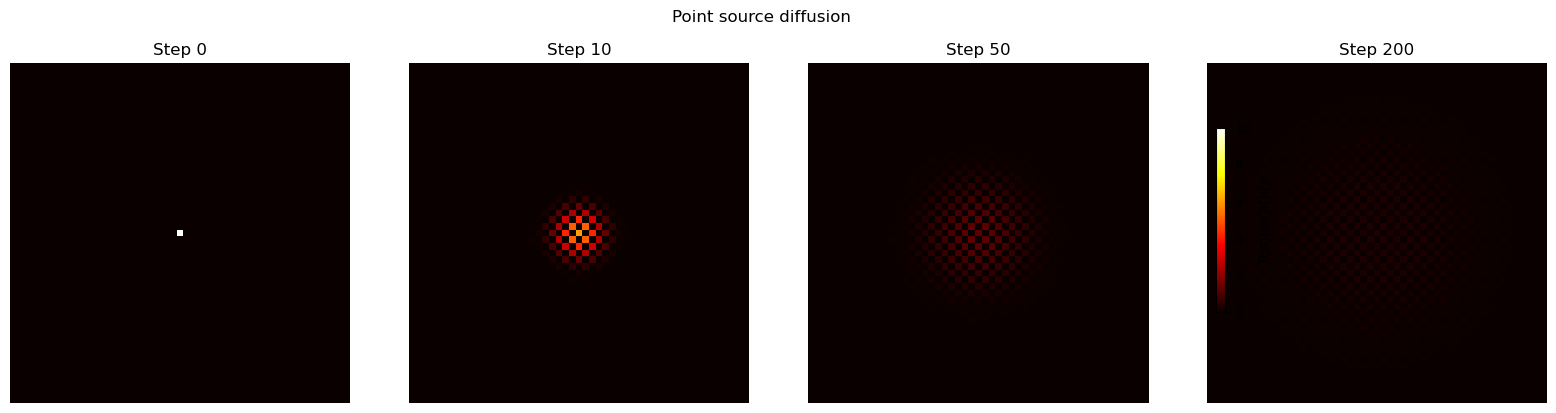

In [2]:
# Create a 51x51 grid with a hot spot at the center
shape = (51, 51)
data = np.zeros(shape)
data[25, 25] = 100.0

initial = xr.DataArray(
    data,
    dims=['y', 'x'],
    attrs={'res': (1.0, 1.0)},
)

# Run diffusion for different step counts
steps_list = [0, 10, 50, 200]
results = {}
for s in steps_list:
    if s == 0:
        results[s] = initial
    else:
        results[s] = diffuse(initial, diffusivity=1.0, steps=s, boundary='nearest')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, s in zip(axes, steps_list):
    im = ax.imshow(results[s].values, cmap='hot', vmin=0, vmax=10)
    ax.set_title(f'Step {s}')
    ax.axis('off')
fig.colorbar(im, ax=axes, shrink=0.6, label='Temperature')
plt.suptitle('Point source diffusion', y=1.02)
plt.tight_layout()
plt.show()

## 2. Boundary modes

The `boundary` parameter controls what happens at the edges: `'nan'`, `'nearest'`, `'reflect'`, or `'wrap'`.

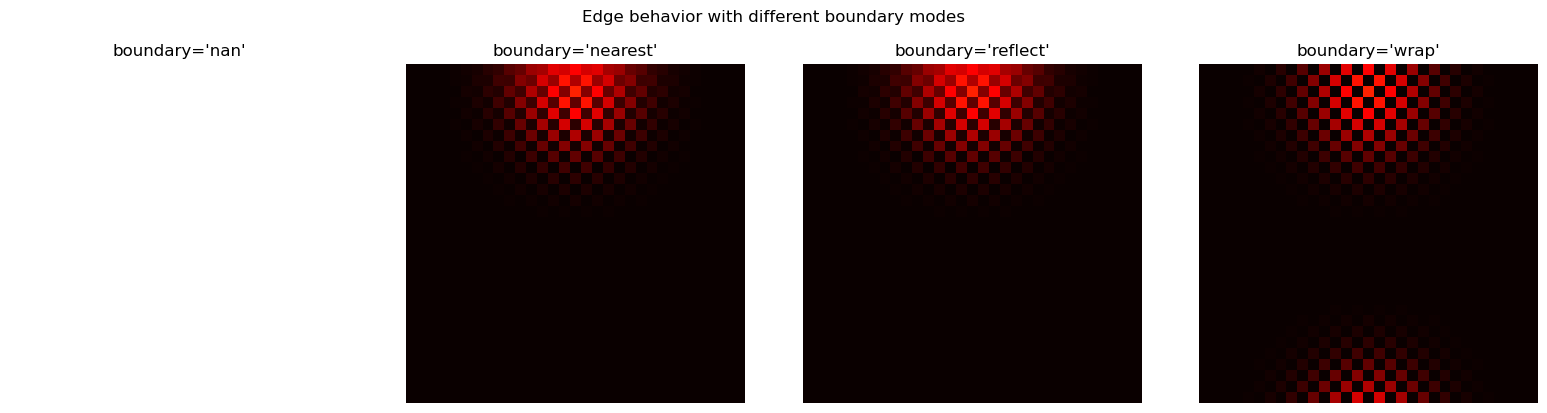

In [3]:
# Hot spot near the edge to highlight boundary behavior
data_edge = np.zeros((31, 31))
data_edge[2, 15] = 100.0

edge_agg = xr.DataArray(
    data_edge, dims=['y', 'x'], attrs={'res': (1.0, 1.0)}
)

boundaries = ['nan', 'nearest', 'reflect', 'wrap']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, bnd in zip(axes, boundaries):
    r = diffuse(edge_agg, diffusivity=1.0, steps=30, boundary=bnd)
    ax.imshow(r.values, cmap='hot', vmin=0, vmax=5)
    ax.set_title(f'boundary={bnd!r}')
    ax.axis('off')
plt.suptitle('Edge behavior with different boundary modes', y=1.02)
plt.tight_layout()
plt.show()

## 3. Spatially varying diffusivity

You can pass a DataArray for `diffusivity` to model materials with different thermal properties. Here we create a wall (low diffusivity) that partially blocks heat flow.

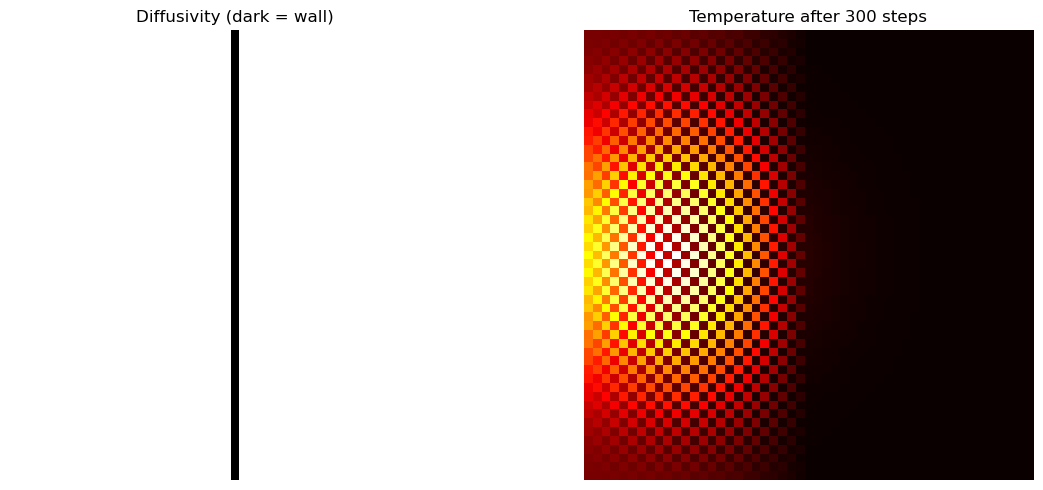

In [4]:
shape = (51, 51)
data = np.zeros(shape)
data[25, 10] = 100.0  # heat source on the left

# Diffusivity field: mostly 1.0, with a vertical wall of low diffusivity
alpha = np.ones(shape)
alpha[:, 25] = 0.01  # thin wall in the middle

field = xr.DataArray(data, dims=['y', 'x'], attrs={'res': (1.0, 1.0)})
alpha_da = xr.DataArray(alpha, dims=['y', 'x'], attrs={'res': (1.0, 1.0)})

result = diffuse(field, diffusivity=alpha_da, steps=300, boundary='nearest')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(alpha, cmap='gray')
axes[0].set_title('Diffusivity (dark = wall)')
axes[0].axis('off')

axes[1].imshow(result.values, cmap='hot', vmin=0)
axes[1].set_title('Temperature after 300 steps')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 4. Practical example: HVAC failure

Simulate what happens when a cooling unit fails in a building floor plan. We start with a comfortable 22 C everywhere, set the failed zone to 35 C, and let heat diffuse.

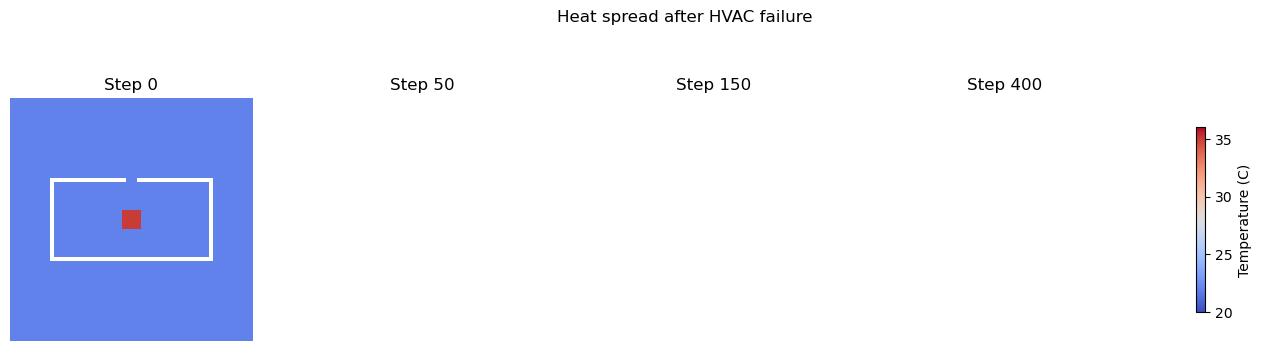

In [7]:
shape = (61, 61)
temp = np.full(shape, 22.0)  # comfortable baseline

# Failed zone: a 5x5 block near center heats up
temp[28:33, 28:33] = 35.0

# Walls (NaN = impassable)
temp[20, 10:50] = np.nan  # horizontal wall
temp[40, 10:50] = np.nan  # horizontal wall
temp[20:41, 10] = np.nan  # left wall
temp[20:41, 50] = np.nan  # right wall
# Door opening
temp[20, 29:32] = 22.0

field = xr.DataArray(temp, dims=['y', 'x'], attrs={'res': (1.0, 1.0)})

snapshots = [0, 50, 150, 400]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, s in zip(axes, snapshots):
    if s == 0:
        r = field
    else:
        r = diffuse(field, diffusivity=0.5, steps=s, boundary='nearest')
    im = ax.imshow(r.values, cmap='coolwarm', vmin=20, vmax=36)
    ax.set_title(f'Step {s}')
    ax.axis('off')
fig.colorbar(im, ax=axes, shrink=0.6, label='Temperature (C)')
plt.suptitle('Heat spread after HVAC failure', y=1.02)

plt.show()